# Spring Drying Analysis — Climate Data Processing Notebook

This notebook computes **climate trends and averages at each spring location** and compares them between springs that have **dried up** and springs that are still **active**.

**Overall workflow:**
1. Load a gridded climate dataset (ERA5-type NetCDF) and a table of field-surveyed springs (location, condition, drying year).
2. For each spring, extract the nearest climate grid cell and compute a **15-year window** of data — anchored either to the year the spring dried, or to the most recent years if it's still active.
3. Run the **Mann–Kendall trend test** on that window to get a trend (Sen's slope) and mean for four variables: dewpoint temperature, air temperature, precipitation, and potential evaporation.
4. Attach these results back to the spring table, merge with previously computed **DEM (terrain), LULC (land cover), and geological** attributes (from other notebooks, via a shared `Full_Analysis_data.csv`), and save.
5. Produce a publication-quality comparison plot of climate variable distributions for **active vs. dried** springs.

Below, each code cell from the original notebook is explained step by step in the markdown cell that precedes it.


## Step 1 — Import required libraries

This cell loads all the Python packages the analysis depends on:

- **`pandas`** – for handling tabular data (the spring inventory table: latitude, longitude, source condition, drying year, etc.)
- **`matplotlib.pyplot`** – for plotting figures later in the notebook.
- **`xarray`** – for working with the multi-dimensional climate NetCDF (`.nc`) file (e.g., ERA5 reanalysis data), which is indexed by latitude, longitude, and time.
- **`pymannkendall.original_test`** – implements the **Mann–Kendall trend test**, a non-parametric statistical test used to detect monotonic (increasing/decreasing) trends in time-series data. It also returns **Sen's slope**, an estimate of the trend's magnitude.
- **`numpy`** – for numerical operations, especially handling `NaN` (missing) values.

**Purpose:** to prepare the environment for reading climate data, computing long-term trends at each spring location, and visualizing the results.


In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import xarray as xr 
from pymannkendall import original_test
import numpy as np

## Step 2 — Load the climate dataset and the spring inventory table

Two datasets are loaded here:

1. **`climatedata`** — a NetCDF climate dataset (`.nc` file) opened with `xarray.open_dataset()`. NetCDF files store gridded climate variables (e.g., temperature, dewpoint temperature, precipitation, evaporation) across latitude, longitude, and time — this is very likely an **ERA5 reanalysis extract** based on the variable names used later (`t2m`, `d2m`, `tp`, `pev`).

2. **`static_csv`** — the spring inventory table, stored as a **pickle file** (`Full_static_data.pkl`) and loaded with `pd.read_pickle()`. This table holds the field-collected information about each spring: latitude, longitude, source condition (active/dried), the year it dried (if applicable), and other seasonal/perennial attributes you mentioned.

**Purpose:** to bring together (a) the gridded climate record and (b) the ground-truth spring locations/status so that climate conditions can later be extracted *at each spring's exact coordinates*.


In [2]:
import os

DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
NC_PATH = os.path.join(DATA_DIR, "baf400466b67369cecb11d5d456ba48c.nc")
ANALYSIS_CSV_PATH = os.path.join(DATA_DIR, "Full_Analysis_data.csv")

climatedata = xr.open_dataset(NC_PATH)

# Full_static_data.pkl is not available in this project; Full_Analysis_data.csv
# already contains the same spring inventory fields (Latitude, Longitude,
# "Dried since how many years?", "Source Condition", etc.), so we use it as
# the source table instead. The leading column is a stray index column from
# a previous to_csv() save, so it is dropped with .iloc[:, 1:].
static_csv = pd.read_csv(ANALYSIS_CSV_PATH).iloc[:, 1:]

## Step 3 — Extract key columns as arrays

Three columns are pulled out of `static_csv` into plain NumPy arrays for fast, repeated access inside the loop that follows:

- **`dried_years`** — the year each spring dried up (if it has). Springs that are still active/flowing will have `NaN` here.
- **`latitude`** / **`longitude`** — the coordinates of each spring, used to look up the nearest climate grid cell.

**Purpose:** working with `.values` (NumPy arrays) instead of the full DataFrame is faster when the same lookup is repeated for every spring in a loop.


In [3]:
dried_years=static_csv["Dried since how many years?"].values
latitude=static_csv["Latitude"].values
longitude=static_csv["Longitude"].values

## Step 4 — Initialize empty result containers

Four empty lists are created to store the **trend slope** (rate of change per year) for each climate variable, one value per spring:

- `dewpoint_rate`
- `temperature_rate`
- `evaporation_rate`
- `precipitation_rate`

**Purpose:** these lists will be filled in later (Step 6) as the analysis loops through every spring in the dataset, and will eventually become new columns in the results table.


In [4]:
dewpoint_rate=[]
temperature_rate=[]
evaporation_rate=[]
precipitation_rate=[]

## Step 5 — Core function: `get_slopes(i)` — extract climate trends for spring *i*

This is the heart of the notebook. For a given spring index `i`, it extracts a **15-year climate window** at that spring's location and computes both the **average value** and the **long-term trend (slope)** of four variables: dewpoint temperature (`d2m`), air temperature (`t2m`), precipitation (`tp`), and potential evaporation (`pev`).

The function branches into **three cases**, depending on the spring's status:

### Case 1 — Spring is still active (`dried_years[i]` is `NaN`)
- The nearest climate grid cell to the spring's `(latitude, longitude)` is selected using `.sel(..., method="nearest")` — this is a **nearest-neighbor spatial lookup**, since the spring's exact coordinates rarely fall exactly on a climate grid point.
- Data is **resampled to annual means** (`resample(valid_time="YE").mean()` — "YE" = year-end, i.e., one average value per calendar year).
- **Unit conversions** are applied:
  - `tp` (total precipitation, originally in meters/day in ERA5) is converted to **mm/year**: `tp * 1000 (m→mm) * 365 (days→year)`.
  - `d2m` and `t2m` (originally in Kelvin) are converted to **°C** by subtracting 273.15.
- The time coordinate is simplified to just the **year** (`.dt.year`).
- The record is filtered to the **most recent 15 years up to 2025** (`2025-15` to `2025`), since the spring is still active and 2025 is treated as the reference "present."
- The **Mann–Kendall test** (`original_test`) is applied to each variable's time series to get:
  - `p` — statistical significance of the trend.
  - `slope` — Sen's slope, i.e., the rate of change per year.
- The **15-year mean** of each variable is also computed.
- Returns `[mean, slope]` pairs for dewpoint, temperature, precipitation, and evaporation.

### Case 2 — Spring dried before 1946 (`dried_years[i] < 1946`)
- Returns `NaN` for everything, because the climate dataset (ERA5) doesn't reliably extend that far back — there isn't a valid 15-year window of data available before the drying event.

### Case 3 — Spring dried in a known year ≥ 1946
- Identical processing to Case 1, **except** the 15-year window is anchored to the spring's own **drying year** instead of 2025: `(dried_years[i]-15, dried_years[i]]`.
- This means the climate trend/mean is computed for the **15 years leading up to when that specific spring dried** — allowing a fair, spring-specific "before drying" climate signature.

**Why this design matters:** Every spring gets its own tailored analysis window — either "the 15 years before it dried" or "the most recent 15 years" if it's still flowing — so that dried and active springs are compared on an equivalent temporal basis rather than a single fixed calendar period.

**Note on `p` (line `p = cdata.apply(...)`)**: the p-values are computed but not returned or stored — only the slope and mean are passed back. If statistical significance filtering is needed later, this variable would need to be captured and returned too.


In [5]:
def get_slopes(i):
    if np.isnan(dried_years[i]):
        cdata=climatedata.sel(latitude=latitude[i],longitude=longitude[i],method="nearest")
        cdata=cdata.resample(valid_time="YE").mean()
        cdata["tp"]=cdata["tp"]*1000*365
        cdata["d2m"]=cdata["d2m"]-273.15
        cdata["t2m"]=cdata["t2m"]-273.15
        cdata["valid_time"]=cdata["valid_time"].dt.year
        cdata=cdata.where((cdata["valid_time"]<=2025)*(cdata["valid_time"]>(2025)-15),drop=True)
        p=cdata.apply(lambda x: original_test(x.values).p)
        slope=cdata.apply(lambda x: original_test(x.values).slope)
        cdata=cdata.mean()
        return [cdata["d2m"].values,slope["d2m"].values],[cdata["t2m"].values,slope["t2m"].values],[cdata["tp"].values,slope["tp"].values],[cdata["pev"].values,slope["pev"].values]
    elif dried_years[i]<1946:
        return [np.nan,np.nan],[np.nan,np.nan],[np.nan,np.nan],[np.nan,np.nan]
    else:
        cdata=climatedata.sel(latitude=latitude[i],longitude=longitude[i],method="nearest")
        cdata=cdata.resample(valid_time="YE").mean()
        cdata["tp"]=cdata["tp"]*1000*365
        cdata["d2m"]=cdata["d2m"]-273.15
        cdata["t2m"]=cdata["t2m"]-273.15
        cdata["valid_time"]=cdata["valid_time"].dt.year
        cdata=cdata.where((cdata["valid_time"]<=dried_years[i])*(cdata["valid_time"]>(dried_years[i])-15),drop=True)
        p=cdata.apply(lambda x: original_test(x.values).p)
        slope=cdata.apply(lambda x: original_test(x.values).slope)
        cdata=cdata.mean()
        return [cdata["d2m"].values,slope["d2m"].values],[cdata["t2m"].values,slope["t2m"].values],[cdata["tp"].values,slope["tp"].values],[cdata["pev"].values,slope["pev"].values]


## Step 6 — Initialize containers for mean values

Similar to Step 4, but this time for the **mean** values of each variable (as opposed to the trend/slope):

- `dewpoint_mean`
- `temperature_mean`
- `evaporation_mean`
- `precipitation_mean`

**Purpose:** to store the average climate conditions (over each spring's relevant 15-year window) alongside the trend information.


In [6]:
dewpoint_mean=[]
temperature_mean=[]
evaporation_mean=[]
precipitation_mean=[]

## Step 7 — Loop through every spring and run the analysis

This loop iterates over **every row** in `static_csv` (i.e., every spring in the inventory):

1. Calls `get_slopes(i)` for the current spring.
2. Unpacks the returned `[mean, rate]` pairs for dewpoint, temperature, precipitation, and evaporation.
3. Appends each value to its corresponding list (created in Steps 4 and 6).

**Purpose:** this is where the per-spring climate extraction and trend computation (defined in Step 5) is actually executed across the **entire dataset**, building up parallel lists of trend rates and mean values — one entry per spring, in the same order as the rows of `static_csv`.


In [7]:
for i in range(len(static_csv)):
    [d_mean,d_rate],[t_mean,t_rate],[p_mean,p_rate],[e_mean,e_rate]=get_slopes(i)
    dewpoint_rate.append(d_rate)
    temperature_rate.append(t_rate)
    precipitation_rate.append(p_rate)
    evaporation_rate.append(e_rate)
    dewpoint_mean.append(d_mean)
    temperature_mean.append(t_mean)
    precipitation_mean.append(p_mean)
    evaporation_mean.append(e_mean)

## Step 8 — Attach trend (rate) columns to the spring table

The four `_rate` lists (Sen's slope values from the Mann–Kendall test) are added back into `static_csv` as new columns:

- `Dewpoint_rate`
- `Temperature_rate`
- `Precipitation_rate`
- `Evaporation_rate`

**Purpose:** each spring now has a quantified **rate of climatic change** (per year) for each variable, over its own relevant time window — this lets you later ask, e.g., "did dried springs experience faster warming or drying trends than active springs?"


In [8]:
static_csv["Dewpoint_rate"]=dewpoint_rate
static_csv["Temperature_rate"]=temperature_rate
static_csv["Precipitation_rate"]=precipitation_rate
static_csv["Evaporation_rate"]=evaporation_rate

## Step 9 — Attach mean-value columns to the spring table

Similarly, the four `_mean` lists are added as new columns:

- `Dewpoint_mean`
- `Temperature_mean`
- `Precipitation_mean`
- `Evaporation_mean`

**Purpose:** each spring now also has its **average climatic condition** (dewpoint, temperature, precipitation, evaporation) over the same 15-year reference window used for the trend calculation. Together with Step 8, `static_csv` now holds both the "state" (mean) and the "change" (rate) of climate at every spring site.


In [9]:
static_csv["Dewpoint_mean"]=dewpoint_mean
static_csv["Temperature_mean"]=temperature_mean
static_csv["Precipitation_mean"]=precipitation_mean
static_csv["Evaporation_mean"]=evaporation_mean

## Step 10 — Build a focused analysis subset (`metdata`)

A new, smaller DataFrame `metdata` is created by selecting only the columns relevant to the meteorological comparison:

- Location: `Latitude`, `Longitude`
- Trends: `Dewpoint_rate`, `Temperature_rate`, `Precipitation_rate`, `Evaporation_rate`
- Averages: `Dewpoint_mean`, `Temperature_mean`, `Precipitation_mean`, `Evaporation_mean`
- Classification: `Source Condition` (e.g., "active" vs. "dried")

**Purpose:** to isolate just the fields needed for the statistical/visual comparison between active and dried springs, dropping the many other static/geological/land-use attributes not needed at this particular stage.


In [10]:
metdata=static_csv[["Latitude","Longitude","Dewpoint_rate","Temperature_rate","Precipitation_rate","Evaporation_rate","Dewpoint_mean","Temperature_mean","Precipitation_mean","Evaporation_mean","Source Condition"]]

## Step 11 — Ensure numeric columns are proper floats

`metdata.iloc[:, 2:-1]` selects all columns **except** the first two (`Latitude`, `Longitude`) and the last one (`Source Condition`) — i.e., all the rate and mean climate columns — and casts them to `float`.

**Purpose:** because these values were built up inside Python lists (via `.append()`) from NumPy scalar arrays, their dtype in the DataFrame can sometimes end up as generic `object` rather than a proper numeric `float64`. Explicitly casting to `float` ensures downstream statistics and plotting functions treat them as numbers, not as arbitrary objects.


In [11]:
metdata.iloc[:,2:-1]=metdata.iloc[:,2:-1].astype(float)

## Step 12 — Reload the full, merged analysis dataset

Here `static_csv` is **overwritten** by reading `Full_Analysis_data.csv` — a CSV file that (based on your description) already contains the **merged results from other processing stages**: SRTM DEM-derived terrain attributes (elevation, slope, aspect, etc.), LULC (Land Use / Land Cover) classification, and geological/lithological attributes, in addition to the meteorological fields computed above.

**Purpose:** this step brings the notebook's climate-derived columns back together with the terrain, land-cover, and geology variables that were presumably computed in **separate notebooks/scripts** (not shown in this file), consolidating everything into one master analysis table.

> **Note:** the DEM, LULC, and geological-data processing steps themselves are *not* part of this particular notebook — this file only handles the climate/meteorological component. `Full_Analysis_data.csv` appears to be the shared output file where all these different analyses (climate, terrain, land cover, geology) converge.


In [12]:
static_csv = pd.read_csv(ANALYSIS_CSV_PATH)

## Step 13 — Save the updated table back to disk

`static_csv.to_csv("Full_Analysis_data.csv")` writes the (reloaded) DataFrame back out to the same CSV file.

**Purpose:** persists any changes made in this session. As written, this cell simply re-saves the data loaded in Step 12 without modification in between — in a typical workflow, you'd insert an update/merge step here (e.g., joining the new climate columns from `metdata` into this table) before saving, so the file accumulates all analysis results in one place.


In [13]:
# NOTE: as originally written, this cell just re-saves the file loaded in the
# previous cell unchanged (it never merges the freshly computed `metdata`
# climate columns back in). To avoid silently overwriting the master
# Full_Analysis_data.csv during a routine run of this notebook, the output is
# written to a separate file instead. Point this back at ANALYSIS_CSV_PATH if
# you intend to replace the master file.
OUTPUT_CSV_PATH = os.path.join(DATA_DIR, "Full_Analysis_data_recomputed.csv")
static_csv.to_csv(OUTPUT_CSV_PATH, index=False)
print("Saved:", OUTPUT_CSV_PATH)

Saved: C:\Users\kants\Desktop\ME Classes\3rd Sem\Thesis & Project\Full_Analysis_data_recomputed.csv


## Step 14 — Visualize: distribution of climate variables by spring condition

This final section produces a **manuscript/publication-quality figure** comparing the distributions of the 8 climate variables (4 rates + 4 means) between **active** and **dried** springs.

Key details:

- **Style settings**: `seaborn`'s clean white background, high DPI (300, suitable for print/publication), serif font (Times New Roman), and bold axis lines/ticks — all chosen to match typical scientific journal figure requirements.
- **Layout**: a 4×2 grid of subplots (`plt.subplots(4, 2, ...)`), one panel per variable (`Dewpoint_rate`, `Temperature_rate`, `Precipitation_rate`, `Evaporation_rate`, `Dewpoint_mean`, `Temperature_mean`, `Precipitation_mean`, `Evaporation_mean`).
- **Color coding**: dark green (`#2E7D32`) for **active** springs, brown (`#8D6E63`) for **dried** springs — an intuitive color choice (green = still flowing, brown = dried up).
- **Histogram construction (per panel)**:
  1. Data is split into `active` vs `dried` groups using the `Source Condition` column, dropping missing values.
  2. Raw counts per bin are computed with `np.histogram()` (20 bins).
  3. Counts are converted to **percentages within each group** (`counts / len(group) * 100`), so that active and dried groups are each normalized to sum to 100% — this makes the two groups directly comparable even if they have very different sample sizes.
  4. Bars for active and dried are plotted **side-by-side** (offset by half a bin width) rather than stacked or overlapping, so both distributions are clearly visible.
- **Formatting**: top/right plot borders removed for a clean look, bold axis labels (variable name and "Percentage (%)"), light dashed horizontal gridlines only, and a legend in each panel.
- **Output**: the composite figure is saved as `manuscript_distribution_plots_correct_percentage.png` at 300 DPI with a white background, and also displayed inline with `plt.show()`.

**Purpose:** this figure is the key **exploratory/comparative visualization** of the whole analysis — it lets you visually assess whether springs that dried up tend to have different climate signatures (e.g., stronger warming trends, lower precipitation, higher evaporation) compared to springs that are still active, which directly supports the hypothesis that climatic change is a driver of spring drying.


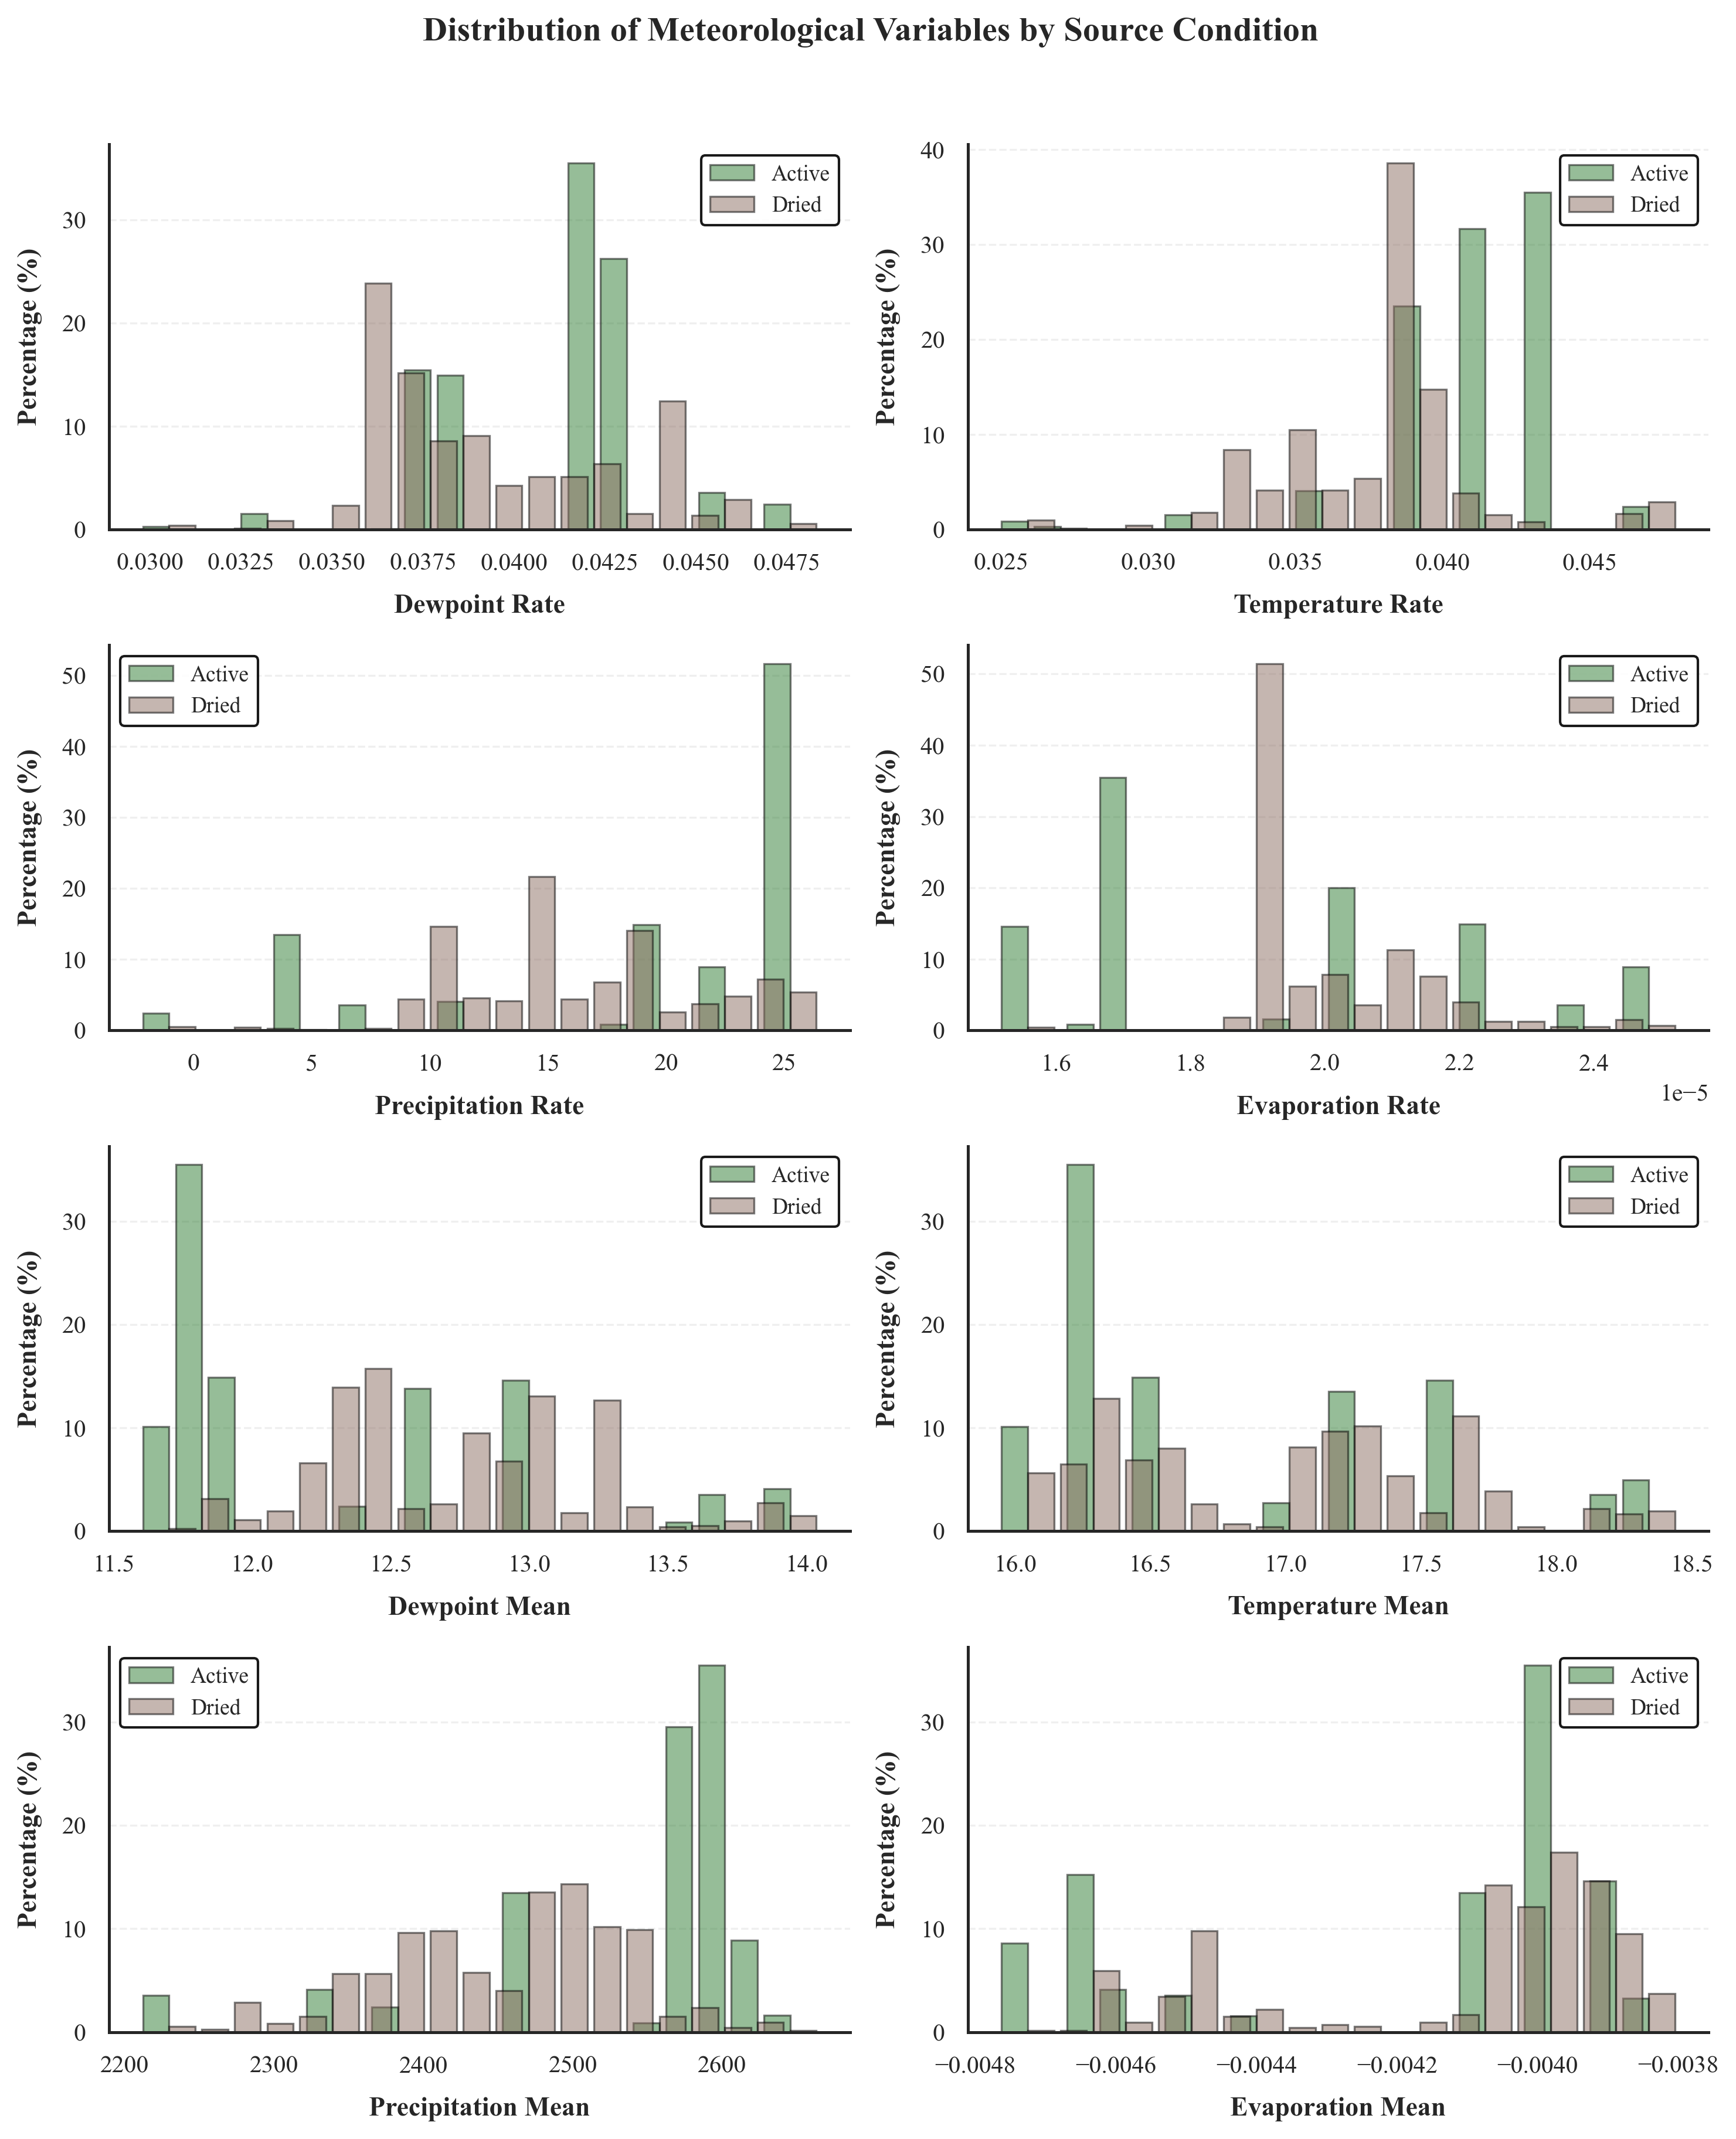

Saved: manuscript_distribution_plots_correct_percentage.png (300 DPI, publication quality)

Each bar shows percentage of observations in that bin
Active and dried each sum to 100% separately


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


# ==== MANUSCRIPT-QUALITY SETTINGS ====
sns.set_style("white")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.major.width'] = 1.2
plt.rcParams['ytick.major.width'] = 1.2
plt.rcParams['xtick.major.size'] = 12
plt.rcParams['ytick.major.size'] = 12


# Columns to plot
columns_to_plot = ['Dewpoint_rate', 'Temperature_rate', 'Precipitation_rate', 
                   'Evaporation_rate', 'Dewpoint_mean', 'Temperature_mean', 
                   'Precipitation_mean', 'Evaporation_mean']


# Create manuscript-quality figure
fig, axes = plt.subplots(4, 2, figsize=(10, 12))
axes = axes.flatten()


# Professional color palette (journal-ready)
colors = {'active': '#2E7D32', 'dried': '#8D6E63'}  # Dark green and brown


for idx, col in enumerate(columns_to_plot):
    ax = axes[idx]
    
    # Filter data by Source Condition
    active_data = metdata[metdata['Source Condition'] == 'active'][col].dropna()
    dried_data = metdata[metdata['Source Condition'] == 'dried'][col].dropna()
    
    # Use fewer bins to avoid percentage > 100% issue
    n_bins = 20  # Reduced from 30
    
    # Plot normalized histograms (density=True integrates to 1)
    # Then manually scale to percentage for better visualization
    counts_active, bins_active = np.histogram(active_data, bins=n_bins, density=False)
    counts_dried, bins_dried = np.histogram(dried_data, bins=n_bins, density=False)
    
    # Convert to percentage of total for each group separately
    pct_active = (counts_active / len(active_data)) * 100
    pct_dried = (counts_dried / len(dried_data)) * 100
    
    # Calculate bin centers for plotting
    bin_centers = (bins_active[:-1] + bins_active[1:]) / 2
    
    # Plot as bar charts with percentage
    width = (bins_active[1] - bins_active[0]) * 0.8
    ax.bar(bin_centers - width/2, pct_active, width=width, alpha=0.5, 
           color=colors['active'], label='Active', edgecolor='black', linewidth=0.8)
    ax.bar(bin_centers + width/2, pct_dried, width=width, alpha=0.5, 
           color=colors['dried'], label='Dried', edgecolor='black', linewidth=0.8)
    
    # Remove top and right spines (clean journal look)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    
    # Labels with proper formatting
    ax.set_xlabel(col.replace('_', ' ').title(), fontsize=11, fontweight='bold', labelpad=8)
    ax.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold', labelpad=8)
    
    # Tick parameters
    ax.tick_params(direction='out', length=6, width=1.2, labelsize=10)
    ax.grid(True, axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
    ax.grid(False, axis='x')
    
    # Format y-ticks as percentage (will automatically be 0-100%)
    ax.tick_params(axis='y', labelsize=10)
    
    # Legend with frame
    legend = ax.legend(frameon=True, framealpha=0.9, fontsize=9, loc='best', 
                       edgecolor='black')
    legend.get_frame().set_linewidth(1.0)


# Overall figure title
fig.suptitle('Distribution of Meteorological Variables by Source Condition', 
             fontsize=14, fontweight='bold', y=0.995, va='bottom')

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig('manuscript_distribution_plots_correct_percentage.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()


print(f"Saved: manuscript_distribution_plots_correct_percentage.png (300 DPI, publication quality)")
print(f"\nEach bar shows percentage of observations in that bin")
print(f"Active and dried each sum to 100% separately")